# EX 1:

In [ ]:
import numpy as np

v = np.array([
    [10,  2, -3,  6, 11],
    [-5,  6,  8,  8,  0],
    [ 9, -1,  1,  2,  1],
    [ 6,  0,  1,  3, -4]
])

w = np.ones_like(v)
print(w)
v + w, v - w


[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


(array([[11,  3, -2,  7, 12],
        [-4,  7,  9,  9,  1],
        [10,  0,  2,  3,  2],
        [ 7,  1,  2,  4, -3]]),
 array([[ 9,  1, -4,  5, 10],
        [-6,  5,  7,  7, -1],
        [ 8, -2,  0,  1,  0],
        [ 5, -1,  0,  2, -5]]))

# EX 2:

100%|██████████| 170M/170M [00:02<00:00, 79.6MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Epoch [1/10] Train Loss: 2.3007, Train Acc: 16.16% Val Loss: 2.2995,   Val Acc: 19.56%
Epoch [2/10] Train Loss: 2.2989, Train Acc: 19.68% Val Loss: 2.2986,   Val Acc: 20.22%
Epoch [3/10] Train Loss: 2.2985, Train Acc: 19.18% Val Loss: 2.2986,   Val Acc: 20.36%
Epoch [4/10] Train Loss: 2.2988, Train Acc: 16.80% Val Loss: 2.2991,   Val Acc: 17.82%
Epoch [5/10] Train Loss: 2.2994, Train Acc: 16.06% Val Loss: 2.2998,   Val Acc: 16.10%
Epoch [6/10] Train Loss: 2.3002, Train Acc: 15.26% Val Loss: 2.3006,   Val Acc: 14.27%
Epoch [7/10] Train Loss: 2.3009, Train Acc: 14.95% Val Loss: 2.3013,   Val Acc: 13.90%
Epoch [8/10] Train Loss: 2.3015, Train Acc: 14.54% Val Loss: 2.3019,   Val Acc: 12.61%
Epoch [9/10] Train Loss: 2.3020, Train Acc: 12.35% Val Loss: 2.3022,   Val Acc: 9.78%
Epoch [10/10] Train Loss: 2.3023, Train Acc: 10.03% Val Loss: 2.3024,   Val Acc: 9.52%


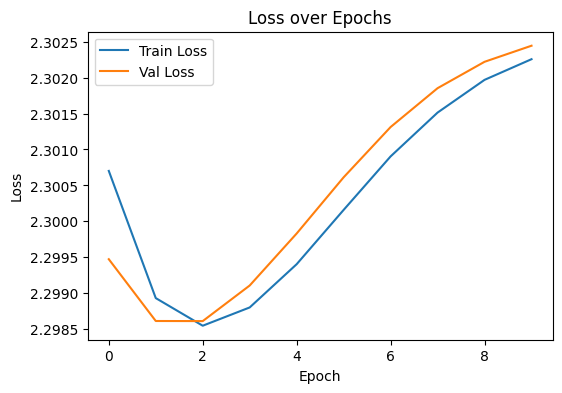

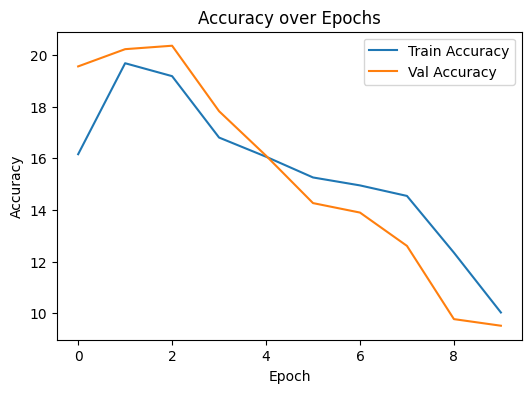


Test Loss: 2.3023, Test Accuracy: 10.00%


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_size = 41000
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 150
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

class MLP(nn.Module):
    def __init__(self, input_dim=32*32*3, hidden_dims=[512, 256, 256], output_dim=10):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], output_dim)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()

def init_weights(m):
    if isinstance(m, nn.Linear):
        if m.in_features == 32*32*3 or m.out_features == 256:
            nn.init.normal_(m.weight, std=0.01)
        else:
            nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_weights)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    weight_decay=0.08
)

def train(model, train_loader, val_loader, loss_fn, optimizer, epochs=10, device='cpu'):
    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        correct_train = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            correct_train += (y_pred.argmax(dim=1) == y).sum().item()

        train_loss = epoch_train_loss / len(train_loader)
        train_acc = 100.0 * correct_train / len(train_loader.dataset)

        model.eval()
        epoch_val_loss = 0
        correct_val = 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)

                y_pred = model(X)
                loss = loss_fn(y_pred, y)

                epoch_val_loss += loss.item()
                correct_val += (y_pred.argmax(dim=1) == y).sum().item()

        val_loss = epoch_val_loss / len(val_loader)
        val_acc = 100.0 * correct_val / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
              f"Val Loss: {val_loss:.4f},   Val Acc: {val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 10
train_losses, train_accs, val_losses, val_accs = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=epochs, device=device
)

def plot_metrics(train_metric, val_metric, metric_name):
    plt.figure(figsize=(6,4))
    plt.plot(train_metric, label=f"Train {metric_name}")
    plt.plot(val_metric, label=f"Val {metric_name}")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} over Epochs")
    plt.legend()
    plt.show()

plot_metrics(train_losses, val_losses, "Loss")
plot_metrics(train_accs, val_accs, "Accuracy")

model.eval()
test_loss = 0
correct = 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        loss = loss_fn(outputs, y)
        test_loss += loss.item()
        correct += (outputs.argmax(dim=1) == y).sum().item()

test_loss /= len(test_loader)
test_accuracy = 100.0 * correct / len(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


# EX 3:

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

class Block1(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.left_conv = nn.Conv2d(input_size, 32, kernel_size=3, padding=1)
        self.left_batchnorm = nn.BatchNorm2d(32)
        self.left_tanh = nn.Tanh()

        self.mid_conv = nn.Conv2d(input_size, 64, kernel_size=3, padding=1)
        self.mid_batchnorm = nn.BatchNorm2d(64)
        self.mid_tanh = nn.Tanh()

        self.right1_conv = nn.Conv2d(input_size, 64, kernel_size=5, padding=2)
        self.right1_batchnorm = nn.BatchNorm2d(64)

        self.right2_conv = nn.Conv2d(64, 32, kernel_size=1, padding=0)
        self.right2_batchnorm = nn.BatchNorm2d(32)
        self.right2_tanh = nn.Tanh()

    def forward(self, input):
        left_output = self.left_tanh(self.left_batchnorm(self.left_conv(input)))
        mid_output = self.mid_tanh(self.mid_batchnorm(self.mid_conv(input)))
        right_output = self.right1_batchnorm(self.right1_conv(input))
        right_output = self.right2_tanh(self.right2_batchnorm(self.right2_conv(right_output)))

        output = torch.cat((left_output, mid_output, right_output), dim=1)
        return output


class ConvolutionalBlock(nn.Module):
    def __init__(self):
        super().__init__()

        self.left_conv = nn.Conv2d(3, 10, kernel_size=5, padding=2)
        self.left_tanh = nn.Tanh()

        self.right1 = Block1(3)
        self.right2 = Block1(128)

    def forward(self, input):
        left_output = self.left_tanh(self.left_conv(input))
        right_output = self.right1(input)
        right_output = self.right2(right_output)

        output = torch.cat((left_output, right_output), dim=1)

        output = F.interpolate(output, size=(28,28), mode='bilinear')
        return output


class net(nn.Module):
    def __init__(self):
        super().__init__()
        self.ConvolutionalBlock = ConvolutionalBlock()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(138 * 28 * 28, 100)

    def forward(self, input, flag=1):
        output = self.ConvolutionalBlock(input)
        if flag:
            print(f"conv block = {output.shape}")
        output = self.flatten(output)
        if flag:
            print(f"Flatten = {output.shape}")
        output = self.linear(output)
        if flag:
            print(f"linear = {output.shape}")
        return output


net = net()


def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)

    mnist_train = torchvision.datasets.CIFAR100(
        root="../data", train=True, transform=trans, download=True
    )
    mnist_test = torchvision.datasets.CIFAR100(
        root="../data", train=False, transform=trans, download=True
    )
    mnist_train, mnist_val = torch.utils.data.random_split(
        mnist_train,
        [35000, 15000],
        generator=torch.Generator().manual_seed(42),
    )
    return (
        torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=2),
        torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False, num_workers=2),
        torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=2),
    )


def evaluate_accuracy(net, data_iter, loss, device):
    net.eval()
    total_loss = 0
    total_hits = 0
    total_samples = 0

    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X, flag=0)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()

    return float(total_loss) / len(data_iter), float(total_hits) / total_samples * 100


def train_epoch(net, train_iter, loss, optimizer, device):
    net.train()
    total_loss = 0
    total_hits = 0
    total_samples = 0

    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        if total_samples != 0:
            y_hat = net(X, flag=0)
        else:
            y_hat = net(X)

        l = loss(y_hat, y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()

        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()

    return float(total_loss) / len(train_iter), float(total_hits) / total_samples * 100


def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []

    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)

        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)

        print(
            f"Epoch {epoch + 1}, Train loss {train_loss:.2f}, "
            f"Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, "
            f"Validation accuracy {val_acc:.2f}"
        )

    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f"Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}")

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all


def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')


def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


batch_size, lr, num_epochs = 512, 0.02, 10
train_iter, val_iter, test_iter = load_data_fashion_mnist(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(
    net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()
)


Files already downloaded and verified
Files already downloaded and verified
Training on cuda:0
conv block = torch.Size([512, 138, 28, 28])
Flatten = torch.Size([512, 108192])
linear = torch.Size([512, 100])
Epoch 1, Train loss 4.44, Train accuracy 11.22, Validation loss 4.15, Validation accuracy 12.16
conv block = torch.Size([512, 138, 28, 28])
Flatten = torch.Size([512, 108192])
linear = torch.Size([512, 100])
Epoch 2, Train loss 3.43, Train accuracy 21.41, Validation loss 3.92, Validation accuracy 14.36
conv block = torch.Size([512, 138, 28, 28])
Flatten = torch.Size([512, 108192])
linear = torch.Size([512, 100])
Epoch 3, Train loss 3.04, Train accuracy 28.16, Validation loss 3.84, Validation accuracy 16.26
conv block = torch.Size([512, 138, 28, 28])
Flatten = torch.Size([512, 108192])
linear = torch.Size([512, 100])
Epoch 4, Train loss 2.77, Train accuracy 33.71, Validation loss 3.89, Validation accuracy 16.09
conv block = torch.Size([512, 138, 28, 28])
Flatten = torch.Size([512, 10

# EX 4:

truthe the the the the the the the the the the the the 
truth as at the dogmand and as at the dogmand and as at
truth and the greater to the desousthes and the greater
truth and the greate ale the certailly which the stregg
truth of the deserves perhaps af the dedise for the des
truth which is not greater as the dogmatists and for th
truth out of the dinge of the distress philosophers int
truth why ecally in europeans and for the trangerous se
truth the possibe the will to demode as a possibes hili
truth the value wo robe the will to delustions it is wi
truth the good and the good and the good and the good a
truth the good and the good all the struggle against th
truth in the truth the grounstoure the truth the grarde
truth all the value opphinx as a presentions and the gr
truthourd it here of the will any which second all the 
truthous as as a philosophers all to truth is the wert 
truth such as as the will to spiles of the beloy for on
truth such as the struggle and which the struggl

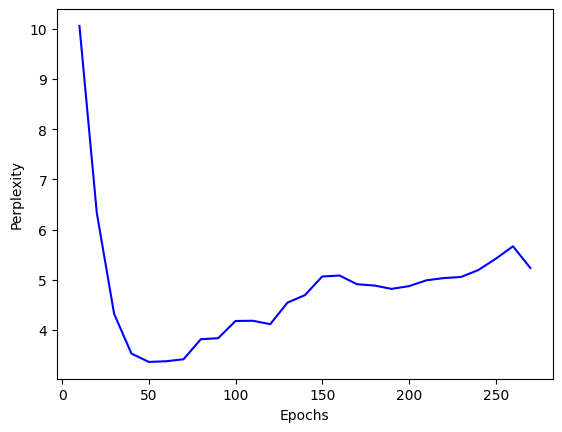

Perplexity at last epoch: 5.2
truth as the pr


In [ ]:
import hashlib
import os
import requests
import re
import collections
import random
import torch
from torch import nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import zipfile

torch.manual_seed(42)
def download(url, cache_dir=os.path.join('..', 'data')):
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def read_nietzsche():
    with open(download('https://s3.amazonaws.com/text-datasets/nietzsche.txt'), 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

def tokenize(lines, token='char'):
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        return []

class Vocab:
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens):
    if len(tokens) == 0 or isinstance(tokens[0], list):
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

def load_corpus_nietzsche(max_tokens=-1):
    lines = read_nietzsche()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

def seq_data_iter_sequential(corpus, batch_size, num_steps):
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

class SeqDataLoader:
    def __init__(self, batch_size, num_steps, max_tokens):
        self.corpus, self.vocab = load_corpus_nietzsche(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return seq_data_iter_sequential(self.corpus, self.batch_size, self.num_steps)

def load_data_nietzsche(batch_size, num_steps, max_tokens=10000):
    data_iter = SeqDataLoader(batch_size, num_steps, max_tokens)
    return data_iter, data_iter.vocab

class RNNModel(nn.Module):
    def __init__(self, rnn_layer, vocab_size):
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        self.linear = nn.Linear(self.num_hiddens, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape(-1, Y.shape[-1]))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            return torch.zeros((self.rnn.num_layers, batch_size, self.num_hiddens), device=device)
        else:
            return (torch.zeros((self.rnn.num_layers, batch_size, self.num_hiddens), device=device),
                    torch.zeros((self.rnn.num_layers, batch_size, self.num_hiddens), device=device))

def predict(prefix, num_preds, net, vocab, device):
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def grad_clipping(net, theta):
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

def train_epoch(net, train_iter, loss, optimizer, device):
    state = None
    total_loss = 0
    total_tokens = 0
    for X, Y in train_iter:
        if state is None:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        optimizer.zero_grad()
        l.backward()
        grad_clipping(net, 1)
        optimizer.step()
        total_loss += float(l * y.numel())
        total_tokens += y.numel()
    return math.exp(total_loss / total_tokens)

def train(net, train_iter, vocab, lr, num_epochs, device):
    loss = nn.CrossEntropyLoss()
    perplexities = []
    optimizer = torch.optim.SGD(net.parameters(), lr)
    for epoch in range(num_epochs):
        ppl = train_epoch(net, train_iter, loss, optimizer, device)
        if (epoch + 1) % 10 == 0:
            print(predict('truth', 50, net, vocab, device))
            perplexities.append(ppl)
    print(f'perplexity {ppl:.1f}, device {str(device)}')
    print(predict('truth', 50, net, vocab, device))
    return perplexities

batch_size, num_steps = 20, 15
train_iter, vocab = load_data_nietzsche(batch_size, num_steps)
vocab_size = len(vocab)
num_hiddens = 48
num_layers = 3
device = try_gpu()
num_epochs = 270
lr = 3
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens, num_layers)
model = RNNModel(gru_layer, vocab_size)
model = model.to(device)
perplexities = train(model, train_iter, vocab, lr, num_epochs, device)

def plot_perplexity(perplexities):
    epochs = range(10, len(perplexities) * 10 + 1, 10)
    plt.plot(epochs, perplexities, 'b')
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity')
    plt.show()

plot_perplexity(perplexities)

print(f'Perplexity at last epoch: {perplexities[-1]:.1f}')
print(predict('truth', 10, model, vocab, device))


# EX 5:

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import os
import requests
import zipfile
import collections

torch.manual_seed(42)


def sequence_mask(X, valid_len, value=0):
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

def masked_softmax(X, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens,
                          value=-1e6)
        return F.softmax(X.reshape(shape), dim=-1)

class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

def transpose_qkv(X, num_heads):
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

class MultiHeadAttention(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        output = self.attention(queries, keys, values, valid_lens)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

class PositionWiseFFN(nn.Module):
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs, dropout=0.25):
        super().__init__()
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(
            self.dropout(
                self.relu(
                    self.dense1(X)
                )
            )
        )

class Network1(nn.Module):
    def __init__(self, num_input, num_hidden=10, num_outputs=64, **kwargs):
        super().__init__(**kwargs)
        self.hidden = nn.Linear(num_input, num_hidden)
        self.out = nn.Linear(num_hidden, num_outputs)

    def forward(self, X):
        H = self.hidden(X)
        return self.out(H)

class Network2(nn.Module):
    def __init__(self, num_input, num_hiddens=28, num_outputs=64, dropout=0.25):
        super().__init__()
        self.layer1 = nn.Linear(num_input, num_hiddens)
        self.layer2 = nn.Linear(num_hiddens, num_hiddens)
        self.output = nn.Linear(num_hiddens, num_outputs)
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(dropout)

    def forward(self, X):
        H1 = self.dropout(self.tanh(self.layer1(X)))
        H2 = self.dropout(self.tanh(self.layer2(H1)))
        return self.dropout(self.output(H2))

class Network3(nn.Module):
    def __init__(self, num_input, num_output, dropout=0.25, **kwargs):
        super().__init__(**kwargs)
        self.layer1 = nn.Linear(num_input, 32)
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, 32)
        self.output = nn.Linear(32, num_output)
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(dropout)

    def forward(self, X):
        H1 = self.dropout(self.tanh(self.layer1(X)))
        H2 = self.dropout(self.tanh(self.layer2(H1)))
        H3 = self.dropout(self.tanh(self.layer3(H2)))
        return self.output(H3)

class AddNorm(nn.Module):
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

class Encoder(nn.Module):
    def __init__(self, **kwargs):
        super(Encoder, self).__init__(**kwargs)

    def forward(self, X, *args):
        raise NotImplementedError

class EncoderBlock(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens, dropout=dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.network1 = Network1(ffn_num_input, net1_num_hiddens, num_hiddens)
        self.network2 = Network2(ffn_num_input, net2_num_hiddens, num_hiddens, dropout=dropout)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.network1(self.attention(X, X, X, valid_lens)))
        Z =  self.addnorm2(Y, self.ffn(Y))
        return self.addnorm3(Z, self.network2(Z))

class TransformerEncoder(Encoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X

class Decoder(nn.Module):
    def __init__(self, **kwargs):
        super(Decoder, self).__init__(**kwargs)

    def init_state(self, enc_outputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

class AttentionDecoder(Decoder):
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    @property
    def attention_weights(self):
        raise NotImplementedError

class DecoderBlock(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, net2_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens, dropout=dropout)
        self.addnorm3 = AddNorm(norm_shape, dropout)
        self.network2 = Network2(ffn_num_input, net2_num_hiddens, num_hiddens, dropout=dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.network2(self.addnorm1(X, X2))
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

class TransformerDecoder(AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, net2_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens, net2_num_hiddens,
                             num_heads, dropout, i))
        self.network3 = Network3(num_hiddens, num_hiddens, dropout=0.25)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        X = self.network3(X)
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)

def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

class Vocab:
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens):
    if len(tokens) == 0 or isinstance(tokens[0], list):
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

def download(url, cache_dir=os.path.join('..', 'data')):
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    else:
        assert False, 'Only zip files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def read_data_nmt():
    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip')
    with open(os.path.join(data_dir, 'fra.txt'), 'r') as f:
        return f.read()

def preprocess_nmt(text):
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)

def tokenize_nmt(text, num_examples=None):
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

def truncate_pad(line, num_steps, padding_token):
    if len(line) > num_steps:
        return line[:num_steps]  # Truncate
    return line + [padding_token] * (num_steps - len(line))  # Pad

def build_array_nmt(lines, vocab, num_steps):
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(
        l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array, valid_len

def load_array(data_arrays, batch_size, is_train=True):
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

def load_data_nmt(batch_size, num_steps, num_examples=600):
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = Vocab(source, min_freq=2,
                          reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=2,
                          reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab

class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(
            pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

def grad_clipping(net, theta):
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    train_loss_all = []
    for epoch in range(num_epochs):
        total_loss = 0
        total_tokens = 0
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)
            Y_hat, _ = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                total_loss += l.sum()
                total_tokens += num_tokens
        if (epoch + 1) % 10 == 0:
            train_loss_all.append(total_loss / total_tokens)
    print(f'loss {total_loss / total_tokens:.3f}, device {str(device)}')
    return train_loss_all

num_hiddens, num_layers, dropout, batch_size, num_steps = 64, 3, 0.25, 32, 7
lr, num_epochs, device = 0.005, 100, try_gpu()
ffn_num_input, ffn_num_hiddens = 32, 64
net1_num_hiddens, net2_num_hiddens, num_heads = 10, 28, 2
key_size, query_size, value_size = 32, 32, 32

norm_shape = [64]

train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)

encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens,
    num_heads, num_layers, dropout)
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, net2_num_hiddens,
    num_heads, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)

train_loss_all = train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)
